In [ ]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv"
)

data = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv"
)

performance = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/07_scheme_performance_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav[
    (nav["date"] >= "2022-01-01") &
    (nav["date"] <= "2026-12-31")
]

nav = nav.merge(
    data[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

avg_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)

fig1 = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Mutual Fund NAV Trend (2022–2026)"
)

fig1.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig1.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig1.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    width=1400,
    xaxis_title="Date",
    yaxis_title="Average NAV"
)

fig1.show()

fig1.write_html(
    "average_nav_trend_2022_2026.html"
)

top10_codes = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)["amfi_code"]
)

nav_top = nav[
    nav["amfi_code"].isin(top10_codes)
]

fig2 = px.line(
    nav_top,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 10 Mutual Funds by AUM - NAV Trend (2022–2026)"
)

fig2.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig2.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig2.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    width=1400,
    legend_title="Scheme",
    legend=dict(
        orientation="h",
        y=-0.3
    )
)

fig2.show()

fig2.write_html(
    "top10_funds_nav_trend.html"
)

print("Charts saved successfully.")

Charts saved successfully.


In [ ]:
scheme_map = data[
    ["amfi_code", "scheme_name"]
].drop_duplicates()

print(scheme_map.sort_values("amfi_code"))

    amfi_code                                        scheme_name
5      100016          HDFC Top 100 Fund - Regular Plan - Growth
9      100025       HDFC Short Term Debt Fund - Regular - Growth
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
28     101206      ABSL Frontline Equity Fund - Regular - Growth
29     101207             ABSL Small Cap Fund - Regular - Growth
30     101208                ABSL Liquid Fund - Regular - Growth
31     102885         UTI Nifty 50 Index Fund - Regular - Growth
32     102886                UTI Mid Cap Fund - Regular - Growth
33     102887              UTI Flexi Cap Fund - Regular - Growth
15     118632     Nippon India Large Cap Fund - Regular - Growth
16     118633      Nippon India Large Cap Fund - Direct - Growth
17     118634     Nippon India Small Cap Fund - Regular - Growth
18     118635                     Nippon India ETF Nifty 50 BeES
19     118636  Nippon India Gilt Securities Fund - Regular - ...
24     119092            

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")

In [ ]:
print(data.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(nav.duplicated().sum())

0


In [ ]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [ ]:
print(fund_house.dtypes)

year            int64
fund_house    float64
aum_crore       int64
dtype: object


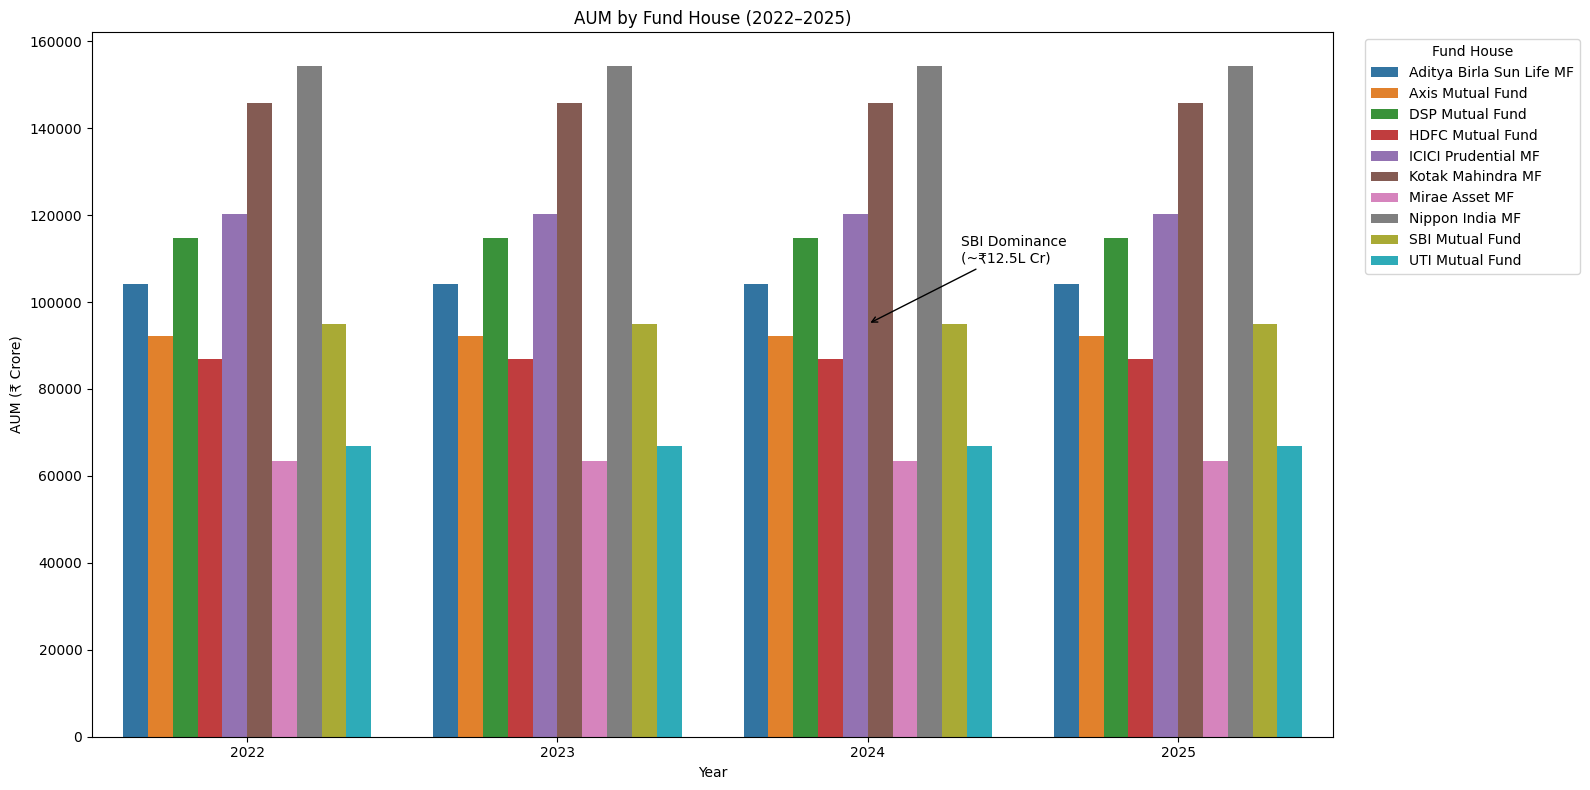

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

scheme = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/07_scheme_performance_clean.csv"
)


data = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv"
)


scheme = scheme.merge(data[['amfi_code', 'fund_house']], on='amfi_code', how='left')

scheme['fund_house'] = scheme['fund_house_y']
scheme = scheme.drop(columns=['fund_house_x', 'fund_house_y'])

years = [2022, 2023, 2024, 2025]

aum_yearly = pd.concat(
    [
        scheme.assign(year=year)
        for year in years
    ],
    ignore_index=True
)

fund_house = (
    aum_yearly
    .groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=fund_house,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

sbi_data = fund_house[
    fund_house["fund_house"].astype(str)
    .str.contains("SBI", case=False, na=False)
]

if not sbi_data.empty:

    max_row = sbi_data.loc[
        sbi_data["aum_crore"].idxmax()
    ]

    plt.annotate(
        "SBI Dominance\n(~₹12.5L Cr)",
        xy=(2, max_row["aum_crore"]),
        xytext=(2.3, max_row["aum_crore"] * 1.15),
        arrowprops=dict(arrowstyle="->")
    )

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
data=pd.read_csv("/content/drive/MyDrive/Google AI Studio/08_investor_transactions.csv")
data['transaction_date']=pd.to_datetime(data['transaction_date'])
sip=data[data['transaction_type']=='SIP'].copy()
monthly_sip=(
    sip.groupby(
        pd.Grouper(
            key='transaction_date',
            freq='M'
        )
    )["amount_inr"]
    .sum()
    .reset_index()
)
monthly_sip.columns=[
  "month",
  "sip_inflow"
]
monthly_sip=monthly_sip[
    (monthly_sip["month"]>="2022-01-01") &
    (monthly_sip["month"]<="2026-12-01")
]
fig=px.line(
    monthly_sip,
    x="month",
    y="sip_inflow",
    markers=True
)
fig.add_annotation(
    x="2025-12-31",
    y=31002,
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    width=1400
)
fig.show()
fig.write_html(
    "sip_inflow_trend_2022_2025.html"
)

/tmp/ipykernel_10316/1125859924.py:8: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [ ]:
print(data.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


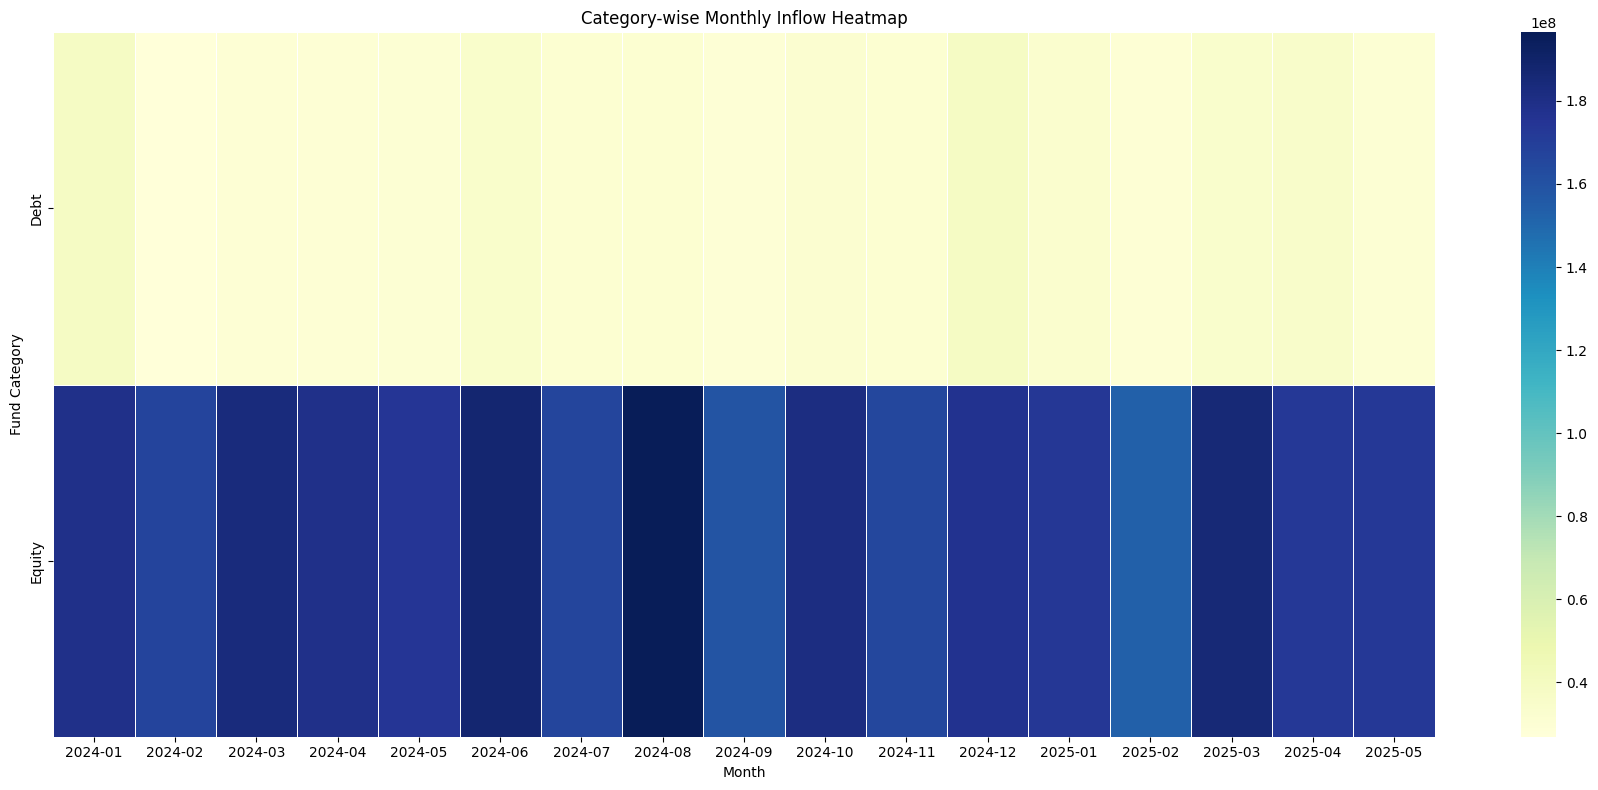

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("/content/drive/MyDrive/Google AI Studio/08_investor_transactions.csv")
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
data['transaction_date']=pd.to_datetime(data['transaction_date'])
data=data.merge(fund[['amfi_code','scheme_name','category']],on='amfi_code',how='left')
data["month"]=data["transaction_date"].dt.strftime("%Y-%m")
heatmap_data=(data.groupby(["category","month"])["amount_inr"].sum().reset_index())
heatmap_matrix=heatmap_data.pivot(
    index="category",
    columns="month",
    values="amount_inr"
)
heatmap_matrix = heatmap_data.pivot(
    index="category",
    columns="month",
    values="amount_inr"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_matrix,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Monthly Inflow Heatmap"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()


In [ ]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [ ]:
import pandas as pd
import plotly.express as px

data = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/08_investor_transactions.csv")

age_dist = (
    data["age_group"]
    .value_counts()
    .reset_index()
)

age_dist.columns = [
    "age_group",
    "count"
]

fig = px.pie(
    age_dist,
    names="age_group",
    values="count",
    title="Investor Age Group Distribution"
)

fig.show()

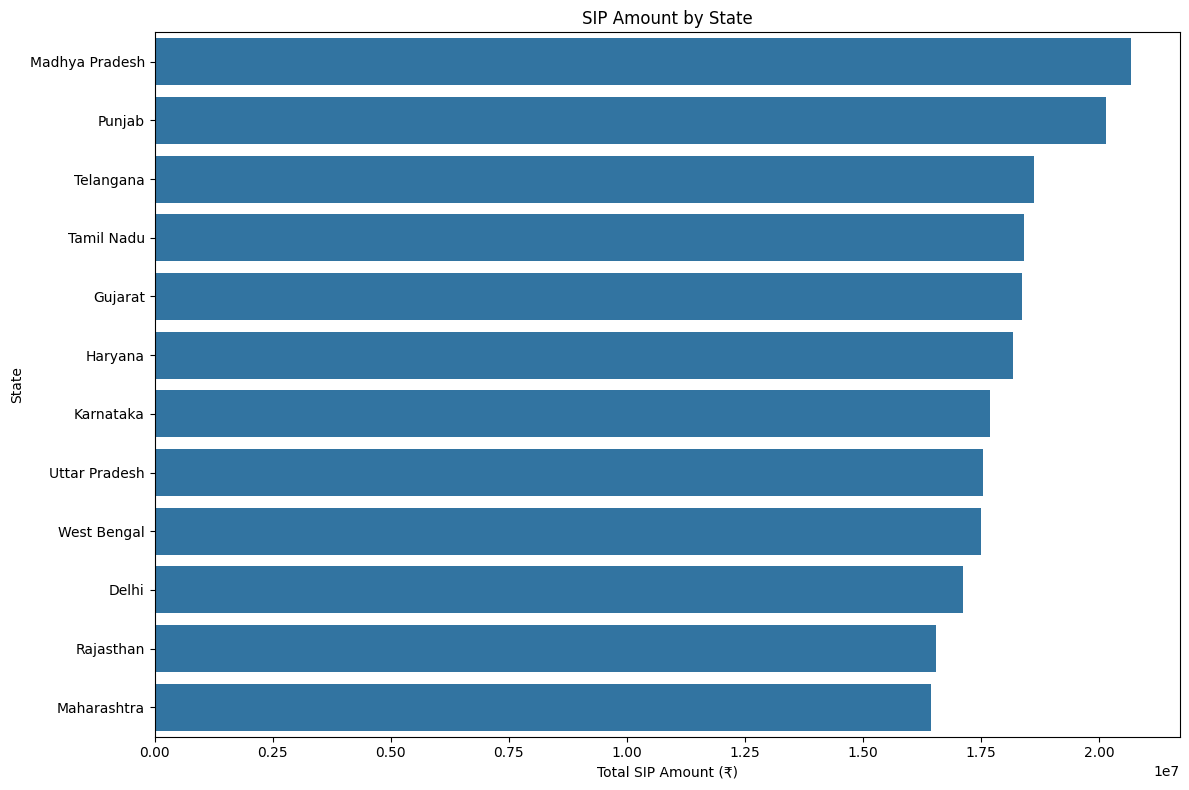

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/08_investor_transactions.csv"
)
sip = data[
    data["transaction_type"] == "SIP"
]
state_sip=sip.groupby("state")["amount_inr"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,8))
sns.barplot(
    data=state_sip,
    y="state",
    x="amount_inr"
)
plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

folio = pd.DataFrame({
    "month": [
        "Jan 2022",
        "Jan 2023",
        "Jan 2024",
        "Jan 2025",
        "Dec 2025"
    ],
    "folios": [
        13.26,
        16.20,
        19.80,
        23.10,
        26.12
    ]
})
fig=px.line(
    folio,
    x="month",
    y="folios",
    markers=True,
    title="Mutual Fund Folio Count Growth (2022–2025)"
)
fig.add_annotation(
    x="Jan 2022",
    y=13.26,
    text="13.26 Cr",
    showarrow=True
    )
fig.add_annotation(
    x="Jan 2024",
    y=16.20,
    text="16.20 Cr",
    showarrow=True
    )
fig.add_annotation(
    x="Dec 2025",
    y=26.12,
    text="26.12 Cr",
    showarrow=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Folios (Crore)"
)

fig.show()

/tmp/ipykernel_2311/3740082213.py:17: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



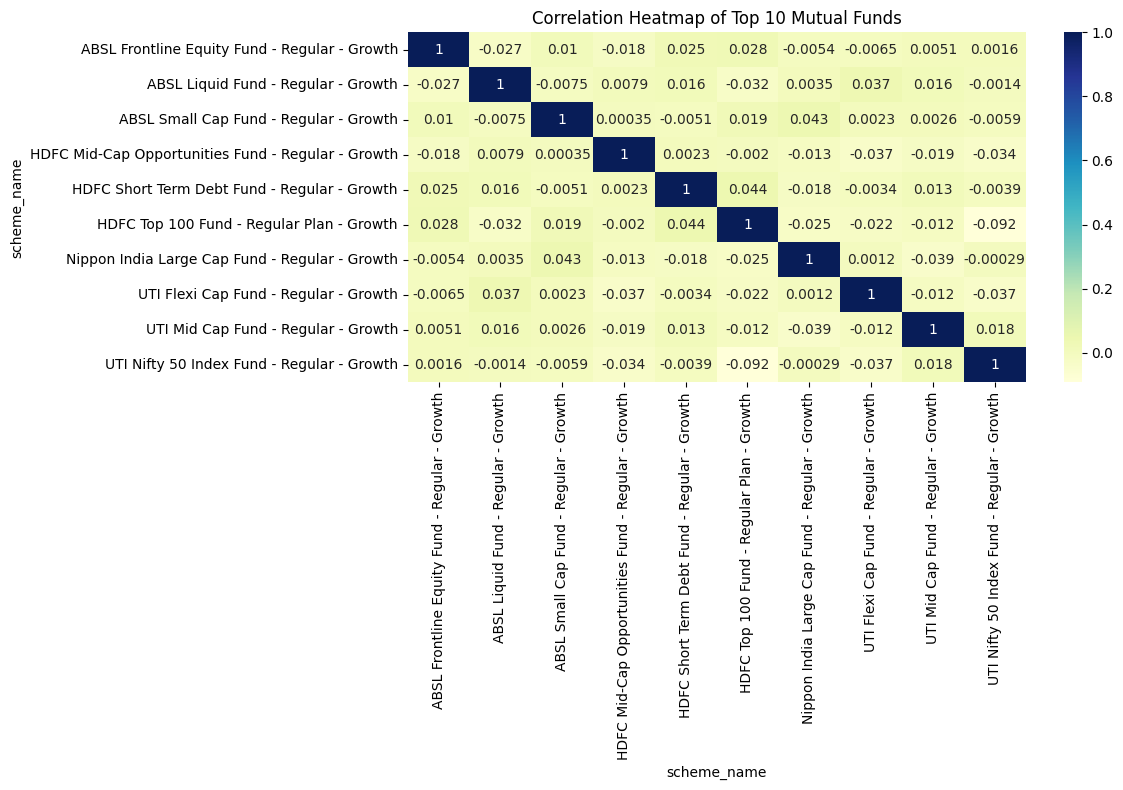

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
nav=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
nav["date"]=pd.to_datetime(nav["date"])
top10_codes=(
    nav["amfi_code"].drop_duplicates().head(10)
)
nav=nav[nav["amfi_code"].isin(top10_codes)]
nav=nav.merge(fund[['amfi_code','scheme_name']],on='amfi_code',how="left")
nav_matrix=nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)
returns=nav_matrix.pct_change()
corr_matrix=returns.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=True
)
plt.title("Correlation Heatmap of Top 10 Mutual Funds")
plt.tight_layout()
plt.show()

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
import pandas as pd
holding=pd.read_csv("/content/drive/MyDrive/Google AI Studio/09_portfolio_holdings.csv")
print(holding.columns.tolist())
sector=holding.groupby("sector")["weight_pct"].sum().reset_index()
fig=px.pie(
    sector,
    names="sector",
    values="weight_pct",
    hole=0.45,
    title="sector allocation across security funds"
)
fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
